<a href="https://colab.research.google.com/github/Analcrs6/Hair-Care-Intelligence-/blob/main/Hair_Care_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")
print("Path:", path)

100%|██████████| 147M/147M [00:01<00:00, 124MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/nadyinky/sephora-products-and-skincare-reviews/versions/2


In [ ]:
import os
import pandas as pd

path = "/root/.cache/kagglehub/datasets/nadyinky/sephora-products-and-skincare-reviews/versions/2"

# ── See all files ────────────────────────────────────────────────────────
for f in sorted(os.listdir(path)):
    size_mb = os.path.getsize(os.path.join(path, f)) / 1e6
    print(f"{f:<45} {size_mb:.1f} MB")

product_info.csv                              7.9 MB
reviews_0-250.csv                             282.3 MB
reviews_1250-end.csv                          24.2 MB
reviews_250-500.csv                           100.3 MB
reviews_500-750.csv                           56.3 MB
reviews_750-1250.csv                          58.0 MB


In [ ]:
# ── Load product info ────────────────────────────────────────────────────
products = pd.read_csv(f"{path}/product_info.csv")
print("=== PRODUCT INFO ===")
print("Shape:", products.shape)
print("Columns:", products.columns.tolist())
print("\nCategories:\n", products['primary_category'].value_counts().head(10))

# ── Load one reviews file to understand structure ────────────────────────
reviews_sample = pd.read_csv(f"{path}/reviews_0-250.csv")  # adjust filename if needed
print("\n=== REVIEWS SAMPLE ===")
print("Shape:", reviews_sample.shape)
print("Columns:", reviews_sample.columns.tolist())
print("\nHair color values:\n", reviews_sample['hair_color'].value_counts())

=== PRODUCT INFO ===
Shape: (8494, 27)
Columns: ['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count', 'rating', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']

Categories:
 primary_category
Skincare           2420
Makeup             2369
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64


/tmp/ipykernel_3896/3231893443.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_sample = pd.read_csv(f"{path}/reviews_0-250.csv")  # adjust filename if needed



=== REVIEWS SAMPLE ===
Shape: (602130, 19)
Columns: ['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']

Hair color values:
 hair_color
brown       218139
blonde      106834
black        96889
auburn       16143
red          13762
brunette      6442
gray          2840
Name: count, dtype: int64


In [ ]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1. Explore product categories for hair ───────────────────────────────
hair_products = products[products['primary_category'] == 'Hair']
print("=== HAIR SUBCATEGORIES ===")
print(hair_products['secondary_category'].value_counts())
print("\nTertiary (sample):")
print(hair_products['tertiary_category'].value_counts().head(20))

# ── 2. Filter to hair color products ────────────────────────────────────
hair_color_products = products[
    products['secondary_category'].str.contains('Color', case=False, na=False) |
    products['tertiary_category'].str.contains('Color|Dye|Tint|Bleach', case=False, na=False)
].copy()
print(f"\n=== HAIR COLOR PRODUCTS ===")
print(f"Count: {len(hair_color_products)}")
print(f"Brands: {hair_color_products['brand_name'].nunique()}")
print(f"Avg rating: {hair_color_products['rating'].mean():.2f}")
print(f"Rating range: {hair_color_products['rating'].min()} – {hair_color_products['rating'].max()}")
print(f"\nTop brands:\n{hair_color_products['brand_name'].value_counts().head(10)}")
print(f"\nMissing ingredients: {hair_color_products['ingredients'].isnull().sum()}")
print(f"\nSample product names:\n{hair_color_products['product_name'].head(10).tolist()}")

# ── 3. Load all review files and filter to hair color products ───────────
import glob

print("\n=== LOADING ALL REVIEW FILES ===")
review_files = sorted(glob.glob(f"{path}/reviews_*.csv"))
print(f"Files found: {len(review_files)}")
for f in review_files:
    print(f"  {os.path.basename(f)}")

# Load and concatenate — filter to hair color products immediately to save RAM
hair_color_ids = set(hair_color_products['product_id'].astype(str))

dfs = []
for f in review_files:
    chunk = pd.read_csv(f, low_memory=False)
    chunk['product_id'] = chunk['product_id'].astype(str)
    filtered = chunk[chunk['product_id'].isin(hair_color_ids)]
    dfs.append(filtered)
    print(f"  {os.path.basename(f)}: {len(chunk):,} rows → {len(filtered):,} hair color reviews")

reviews = pd.concat(dfs, ignore_index=True)
print(f"\nTotal hair color reviews: {len(reviews):,}")
print(f"Memory: {reviews.memory_usage(deep=True).sum()/1e6:.1f} MB")

# ── 4. Merge products + reviews ──────────────────────────────────────────
df = reviews.merge(
    hair_color_products[['product_id', 'brand_name', 'product_name',
                          'rating', 'ingredients', 'price_usd',
                          'loves_count', 'highlights', 'secondary_category']],
    on='product_id',
    how='left',
    suffixes=('_review', '_product')
)

print(f"\n=== MERGED DATASET ===")
print(f"Shape: {df.shape}")
print(f"Unique products: {df['product_id'].nunique()}")
print(f"Unique brands: {df['brand_name_product'].nunique()}")
print(f"Review rating distribution:\n{df['rating_review'].value_counts().sort_index()}")
print(f"\nHair color of reviewers:\n{df['hair_color'].value_counts()}")
print(f"\nMissing review_text: {df['review_text'].isnull().sum()}")

=== HAIR SUBCATEGORIES ===
secondary_category
Hair Styling & Treatments    757
Shampoo & Conditioner        431
Tools                        153
Value & Gift Sets             91
Mini Size                     28
Shop by Concern                4
Name: count, dtype: int64

Tertiary (sample):
tertiary_category
Hair Styling Products              255
Shampoo                            238
Conditioner                        193
Hair Masks                         120
Scalp Treatments                   120
Hair Oil                            65
Leave-In Conditioner                59
Brushes & Combs                     45
Hair Primers                        43
Dry Shampoo                         41
Accessories                         30
Hair Spray                          28
Curling Irons                       27
Hair Dryers                         26
Hair Straighteners & Flat Irons     25
Hair Supplements                    19
Hair Dye & Root Touch-Ups            5
Color Care                   

In [ ]:
# ── 1. Inspect what tertiary categories actually exist ───────────────────
print("=== ALL TERTIARY CATEGORIES WITH 'COLOR' OR 'DYE' ===")
print(products['tertiary_category'].value_counts())

print("\n=== SAMPLE PRODUCT IDS — PRODUCTS TABLE ===")
print(products['product_id'].dtype)
print(products['product_id'].head(5).tolist())

print("\n=== SAMPLE PRODUCT IDS — REVIEWS TABLE ===")
print(reviews_sample['product_id'].dtype)
print(reviews_sample['product_id'].head(5).tolist())

# ── 2. Correct hair color filter — use tertiary category only ────────────
hair_color_products = products[
    products['tertiary_category'].isin([
        'Hair Dye & Root Touch-Ups',
        'Color Care'
    ])
].copy()

print(f"\n=== CORRECTED HAIR COLOR PRODUCTS ===")
print(f"Count: {len(hair_color_products)}")
print(f"Brands:\n{hair_color_products['brand_name'].value_counts()}")
print(f"\nProduct names:\n{hair_color_products['product_name'].tolist()}")
print(f"\nProduct IDs (first 5): {hair_color_products['product_id'].head(5).tolist()}")
print(f"Product ID dtype: {hair_color_products['product_id'].dtype}")

=== ALL TERTIARY CATEGORIES WITH 'COLOR' OR 'DYE' ===
tertiary_category
Perfume                      568
Moisturizers                 386
Face Serums                  379
Rollerballs & Travel Size    287
Hair Styling Products        255
                            ... 
Under-Eye Concealer            3
Sunscreen                      2
Hair Thinning & Hair Loss      2
Damaged Hair                   1
Manicure & Pedicure Tools      1
Name: count, Length: 118, dtype: int64

=== SAMPLE PRODUCT IDS — PRODUCTS TABLE ===
object
['P473671', 'P473668', 'P473662', 'P473660', 'P473658']

=== SAMPLE PRODUCT IDS — REVIEWS TABLE ===
object
['P504322', 'P420652', 'P420652', 'P420652', 'P420652']

=== CORRECTED HAIR COLOR PRODUCTS ===
Count: 8
Brands:
brand_name
COLOR WOW            3
Oribe                2
Bumble and bumble    1
Good Dye Young       1
IGK                  1
Name: count, dtype: int64

Product names:
['Bb. Color Stick', 'Root Coverup Powder', 'Color Control Purple Toning + Styling Foam 

## Data Scope Decision: Hair Color → Full Hair Portfolio

**Initial approach:** Filter to Hair Color products only, mirroring the
specific focus of the L'Oréal Hair Color Development role.

**Finding:** The Sephora dataset contains only 8 hair color/dye products
(tertiary category: `Hair Dye & Root Touch-Ups`, `Color Care`), primarily
color maintenance and toning products rather than permanent dye formulations.
This is a Sephora-specific limitation — they stock limited permanent hair
color SKUs compared to specialty beauty retailers.

**Decision:** Broaden scope to the full Hair portfolio (1,464 products,
68 brands) for the following reasons:

1. L'Oréal R&I's Hair Color team works across the full hair ecosystem —
   color-safe shampoos, protective treatments, and styling products are
   all within scope
2. 8 products cannot support statistically meaningful NLP or predictive
   modelling
3. Ingredient intelligence derived from 1,464 products is more actionable
   for a formulation team than insights from 8

**Reframed project title:** *Hair Care Intelligence: Consumer Voice,
Ingredient Impact & Performance Dashboard*

This scope change reflects how real data science projects evolve —
initial hypotheses are tested against data availability and adjusted
accordingly.

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import warnings
warnings.filterwarnings('ignore')

path = "/root/.cache/kagglehub/datasets/nadyinky/sephora-products-and-skincare-reviews/versions/2"

# ── 1. Filter products to Hair category ─────────────────────────────────
products = pd.read_csv(f"{path}/product_info.csv")

hair_products = products[
    products['primary_category'] == 'Hair'
].copy()

print("=== HAIR PRODUCTS ===")
print(f"Total: {len(hair_products)}")
print(f"Brands: {hair_products['brand_name'].nunique()}")
print(f"Missing ingredients: {hair_products['ingredients'].isnull().sum()}")
print(f"\nSecondary categories:\n{hair_products['secondary_category'].value_counts()}")
print(f"\nTertiary categories:\n{hair_products['tertiary_category'].value_counts().head(20)}")
print(f"\nRating summary:\n{hair_products['rating'].describe().round(2)}")
print(f"\nTop 10 brands by product count:\n{hair_products['brand_name'].value_counts().head(10)}")

# ── 2. Load all reviews and filter to hair products ──────────────────────
hair_ids = set(hair_products['product_id'].astype(str))

review_files = sorted(glob.glob(f"{path}/reviews_*.csv"))
dfs = []
for f in review_files:
    chunk = pd.read_csv(f, low_memory=False)
    chunk['product_id'] = chunk['product_id'].astype(str)
    filtered = chunk[chunk['product_id'].isin(hair_ids)]
    dfs.append(filtered)
    print(f"{os.path.basename(f)}: {len(chunk):,} total → {len(filtered):,} hair reviews")

reviews = pd.concat(dfs, ignore_index=True)
print(f"\nTotal hair reviews: {len(reviews):,}")
print(f"Memory: {reviews.memory_usage(deep=True).sum()/1e6:.1f} MB")

# ── 3. Merge ─────────────────────────────────────────────────────────────
df = reviews.merge(
    hair_products[[
        'product_id', 'product_name', 'brand_name',
        'rating', 'ingredients', 'price_usd', 'loves_count',
        'highlights', 'secondary_category', 'tertiary_category'
    ]],
    on='product_id',
    how='left',
    suffixes=('_review', '_product')
)

print(f"\n=== MERGED DATASET ===")
print(f"Shape: {df.shape}")
print(f"Unique products: {df['product_id'].nunique()}")
print(f"Review rating distribution:\n{df['rating_review'].value_counts().sort_index()}")
print(f"\nHair color of reviewers:\n{df['hair_color'].value_counts()}")
print(f"\nMissing review_text: {df['review_text'].isnull().sum()}")
print(f"\nSample review:\n{df['review_text'].dropna().iloc[0]}")

=== HAIR PRODUCTS ===
Total: 1464
Brands: 68
Missing ingredients: 190

Secondary categories:
secondary_category
Hair Styling & Treatments    757
Shampoo & Conditioner        431
Tools                        153
Value & Gift Sets             91
Mini Size                     28
Shop by Concern                4
Name: count, dtype: int64

Tertiary categories:
tertiary_category
Hair Styling Products              255
Shampoo                            238
Conditioner                        193
Hair Masks                         120
Scalp Treatments                   120
Hair Oil                            65
Leave-In Conditioner                59
Brushes & Combs                     45
Hair Primers                        43
Dry Shampoo                         41
Accessories                         30
Hair Spray                          28
Curling Irons                       27
Hair Dryers                         26
Hair Straighteners & Flat Irons     25
Hair Supplements                    19


IndexError: single positional indexer is out-of-bounds

## Data Discovery: Diagnosing the Reviews Join

During initial loading, the merge between hair products and reviews returned
0 matches. Rather than discarding the work, the diagnostic process below
documents how the issue was identified — a common real-world data engineering
challenge when working with multi-table datasets from different sources.

This section walks through the debugging steps taken to understand the
dataset structure before proceeding with the correct approach.

In [ ]:
# ── Check exact product ID format in both tables ─────────────────────────
print("=== PRODUCT IDs IN HAIR PRODUCTS ===")
print(hair_products['product_id'].head(10).tolist())
print("dtype:", hair_products['product_id'].dtype)

print("\n=== PRODUCT IDs IN REVIEWS ===")
sample_reviews = pd.read_csv(f"{path}/reviews_0-250.csv", low_memory=False, nrows=5000)
print(sample_reviews['product_id'].head(10).tolist())
print("dtype:", sample_reviews['product_id'].dtype)

# ── Check for overlap ────────────────────────────────────────────────────
hair_ids_list = hair_products['product_id'].astype(str).tolist()
review_ids_sample = sample_reviews['product_id'].astype(str).tolist()

overlap = set(hair_ids_list) & set(review_ids_sample)
print(f"\nOverlap between hair product IDs and first 5k review IDs: {len(overlap)}")

# ── Check what product IDs ARE in the reviews ────────────────────────────
print("\n=== SAMPLE REVIEW PRODUCT IDs ===")
print(sample_reviews['product_id'].value_counts().head(10))

# ── Check if any hair product IDs appear anywhere in reviews ─────────────
print("\n=== SPOT CHECK — first 3 hair product IDs in full reviews file ===")
check_ids = hair_products['product_id'].astype(str).head(3).tolist()
print("Looking for:", check_ids)

full_chunk = pd.read_csv(f"{path}/reviews_0-250.csv", low_memory=False)
for pid in check_ids:
    match = full_chunk[full_chunk['product_id'].astype(str) == pid]
    print(f"  {pid}: {len(match)} matches")

# ── Check what categories the reviewed products belong to ────────────────
print("\n=== CATEGORIES OF REVIEWED PRODUCTS (sample) ===")
reviewed_ids = sample_reviews['product_id'].astype(str).unique()[:20]
matched = products[products['product_id'].astype(str).isin(reviewed_ids)]
print(matched[['product_id', 'product_name', 'primary_category']].head(20))

=== PRODUCT IDs IN HAIR PRODUCTS ===
['P457232', 'P474806', 'P457233', 'P474808', 'P457234', 'P474804', 'P481372', 'P457237', 'P457236', 'P474807']
dtype: object

=== PRODUCT IDs IN REVIEWS ===
['P504322', 'P420652', 'P420652', 'P420652', 'P420652', 'P420652', 'P420652', 'P420652', 'P420652', 'P420652']
dtype: object

Overlap between hair product IDs and first 5k review IDs: 0

=== SAMPLE REVIEW PRODUCT IDs ===
product_id
P420652    4999
P504322       1
Name: count, dtype: int64

=== SPOT CHECK — first 3 hair product IDs in full reviews file ===
Looking for: ['P457232', 'P474806', 'P457233']
  P457232: 0 matches
  P474806: 0 matches
  P457233: 0 matches

=== CATEGORIES OF REVIEWED PRODUCTS (sample) ===
     product_id                                       product_name  \
4431    P420652  Lip Sleeping Mask Intense Hydration with Vitam...   
5539    P504322                     Gentle Hydra-Gel Face Cleanser   

     primary_category  
4431         Skincare  
5539         Skincare  


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

path = "/root/.cache/kagglehub/datasets/nadyinky/sephora-products-and-skincare-reviews/versions/2"

products = pd.read_csv(f"{path}/product_info.csv")
hair = products[products['primary_category'] == 'Hair'].copy()

# ── Basic cleanup ────────────────────────────────────────────────────────
hair = hair[hair['ingredients'].notna()].copy()   # drop 190 missing ingredients
hair = hair[hair['rating'].notna()].copy()         # drop missing ratings
hair['rating'] = hair['rating'].astype(float)

print(f"Working dataset: {len(hair)} products, {hair['brand_name'].nunique()} brands")
print(f"Rating range: {hair['rating'].min():.2f} – {hair['rating'].max():.2f}")

# ── Explore highlights column ────────────────────────────────────────────
print("\n=== HIGHLIGHTS COLUMN (first 10) ===")
print(hair['highlights'].dropna().head(10).tolist())

print(f"\nMissing highlights: {hair['highlights'].isnull().sum()}")

# ── Parse highlights into individual tags ────────────────────────────────
hair['highlights_list'] = hair['highlights'].fillna('').apply(
    lambda x: [h.strip() for h in str(x).split(',') if h.strip()]
)

from collections import Counter
all_tags = [tag for tags in hair['highlights_list'] for tag in tags]
tag_counts = Counter(all_tags)

print("\n=== TOP 30 HIGHLIGHT TAGS ===")
for tag, count in tag_counts.most_common(30):
    print(f"  {tag:<40} {count}")

# ── Rating distribution by tertiary category ─────────────────────────────
print("\n=== AVG RATING BY TERTIARY CATEGORY ===")
cat_summary = hair.groupby('tertiary_category').agg(
    n         = ('rating', 'count'),
    avg_rating = ('rating', 'mean'),
    avg_price  = ('price_usd', 'mean'),
    avg_loves  = ('loves_count', 'mean')
).sort_values('avg_rating', ascending=False).round(2)
print(cat_summary)

# ── Ingredient quick look ────────────────────────────────────────────────
print("\n=== INGREDIENT COLUMN SAMPLE ===")
print(hair['ingredients'].iloc[0][:300])
print("\nAvg ingredient list length (chars):",
      hair['ingredients'].str.len().mean().round(0))

Working dataset: 1232 products, 62 brands
Rating range: 1.00 – 5.00

=== HIGHLIGHTS COLUMN (first 10) ===
["['Vegan', 'Clean at Sephora', 'All Hair Types', 'Coily Hair', 'Without Silicones', 'Good for: Flaky/Dry Scalp']", "['Good for: Damage', 'Good for: Color Care', 'Clean at Sephora', 'All Hair Types', 'Good for: Frizz', 'Without Silicones']", "['Clean at Sephora', 'All Hair Types', 'Curl-Enhancing', 'Coily Hair', 'Without Parabens']", "['Good for: Damage', 'Vegan', 'Clean at Sephora', 'All Hair Types', 'Without Silicones', 'Increases Shine']", "['Unisex/ Genderless Scent', 'Clean at Sephora', 'Coily Hair', 'Curly Hair', 'Without Sulfates SLS & SLES', 'Good for: Flaky/Dry Scalp']", "['Clean at Sephora', 'All Hair Types', 'Without Silicones', 'Without Sulfates SLS & SLES', 'Increases Shine', 'Good for: Oily Scalp']", "['Clean at Sephora', 'All Hair Types', 'Good for: Frizz', 'Good for: Dryness', 'Without Sulfates SLS & SLES', 'Increases Shine']", "['Clean at Sephora', 'All Hair Types'

In [ ]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer
import re

# ══════════════════════════════════════════════════════════════════════════
# MODULE 1 — NLP: Highlights Parsing + Ingredient Feature Engineering
# ══════════════════════════════════════════════════════════════════════════

# ── 1. Fix highlights parsing ────────────────────────────────────────────
def parse_highlights(val):
    if pd.isna(val):
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [h.strip().strip("'\"") for h in parsed]
    except:
        pass
    return [h.strip().strip("'\"[]") for h in str(val).split(',') if h.strip()]

hair['highlights_clean'] = hair['highlights'].apply(parse_highlights)

print("=== CLEANED HIGHLIGHTS (first 3) ===")
for h in hair['highlights_clean'].head(3).tolist():
    print(h)

# ── 2. Top highlights by frequency ──────────────────────────────────────
from collections import Counter
all_tags = [t for tags in hair['highlights_clean'] for t in tags]
tag_freq = Counter(all_tags)

print("\n=== TOP 20 CLEAN HIGHLIGHT TAGS ===")
for tag, count in tag_freq.most_common(20):
    print(f"  {count:>4}  {tag}")

# ── 3. Key ingredient extraction ────────────────────────────────────────
# We look for presence of high-signal ingredients known to L'Oréal R&I
key_ingredients = {
    'keratin':         r'keratin',
    'argan_oil':       r'argania spinosa|argan',
    'coconut_oil':     r'cocos nucifera|coconut oil',
    'shea_butter':     r'butyrospermum parkii|shea butter',
    'hyaluronic_acid': r'hyaluronic acid|sodium hyaluronate',
    'niacinamide':     r'niacinamide',
    'biotin':          r'biotin|vitamin h',
    'caffeine':        r'caffeine',
    'zinc':            r'zinc',
    'glycerin':        r'glycerin',
    'castor_oil':      r'ricinus communis|castor',
    'aloe_vera':       r'aloe barbadensis|aloe vera',
    'dimethicone':     r'dimethicone',
    'sulfate_sls':     r'sodium lauryl sulfate|sodium laureth sulfate',
    'parabens':        r'paraben',
    'silicone':        r'silicone|cyclomethicone|cyclopentasiloxane',
    'panthenol':       r'panthenol|provitamin b5',
    'collagen':        r'collagen|hydrolyzed collagen',
    'tea_tree':        r'melaleuca alternifolia|tea tree',
    'rosemary':        r'rosmarinus officinalis|rosemary',
}

ingr_lower = hair['ingredients'].str.lower().fillna('')
for ing, pattern in key_ingredients.items():
    hair[f'has_{ing}'] = ingr_lower.str.contains(pattern, regex=True).astype(int)

ingredient_cols = [f'has_{k}' for k in key_ingredients]
print("\n=== INGREDIENT PREVALENCE (% of products) ===")
prev = hair[ingredient_cols].mean().sort_values(ascending=False) * 100
for col, pct in prev.items():
    print(f"  {col.replace('has_',''):<20} {pct:.1f}%")

# ── 4. Ingredient impact on rating ──────────────────────────────────────
print("\n=== INGREDIENT IMPACT ON RATING (avg rating with vs without) ===")
print(f"{'Ingredient':<20} {'With':>6} {'Without':>8} {'Delta':>7} {'n_with':>8}")
print("-" * 55)
for col in ingredient_cols:
    name = col.replace('has_', '')
    with_ing    = hair[hair[col] == 1]['rating'].mean()
    without_ing = hair[hair[col] == 0]['rating'].mean()
    delta = with_ing - without_ing
    n_with = hair[col].sum()
    print(f"  {name:<18} {with_ing:>6.3f} {without_ing:>8.3f} {delta:>+7.3f} {n_with:>8}")

# ── 5. MultiLabel binarize highlights for Module 2 ───────────────────────
mlb = MultiLabelBinarizer()
highlights_matrix = mlb.fit_transform(hair['highlights_clean'])
highlights_df = pd.DataFrame(
    highlights_matrix,
    columns=mlb.classes_,
    index=hair.index
)

# Keep only tags that appear in 20+ products
tag_counts_series = highlights_df.sum()
common_tags = tag_counts_series[tag_counts_series >= 20].index.tolist()
highlights_df = highlights_df[common_tags]

print(f"\n=== HIGHLIGHTS BINARY MATRIX ===")
print(f"Shape: {highlights_df.shape}")
print(f"Tags kept (>=20 products): {len(common_tags)}")
print(f"Sample tags: {common_tags[:10]}")

=== CLEANED HIGHLIGHTS (first 3) ===
['Vegan', 'Clean at Sephora', 'All Hair Types', 'Coily Hair', 'Without Silicones', 'Good for: Flaky/Dry Scalp']
['Good for: Damage', 'Good for: Color Care', 'Clean at Sephora', 'All Hair Types', 'Good for: Frizz', 'Without Silicones']
['Clean at Sephora', 'All Hair Types', 'Curl-Enhancing', 'Coily Hair', 'Without Parabens']

=== TOP 20 CLEAN HIGHLIGHT TAGS ===
   611  All Hair Types
   411  Vegan
   381  Good for: Dryness
   355  Increases Shine
   348  Good for: Frizz
   300  Without Sulfates SLS & SLES
   295  Good for: Damage
   235  Hydrating
   229  Clean at Sephora
   200  Good for: Color Care
   176  Without Parabens
   172  Without Silicones
   143  Cruelty-Free
   141  Good for: Volume
   140  Curl-Enhancing
   133  Heat Protection
   116  Curly Hair
   109  Good for: Flaky/Dry Scalp
   105  Good for: Hair Thinning
    98  Clean + Planet Positive

=== INGREDIENT PREVALENCE (% of products) ===
  glycerin             75.8%
  dimethicone      

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import shap
import numpy as np

# ── Reset all indices consistently ───────────────────────────────────────
hair = hair.reset_index(drop=True)
highlights_df = highlights_df.reset_index(drop=True)

# ── 1. Build feature matrix ───────────────────────────────────────────────
ingredient_features = hair[ingredient_cols].copy()

cat_dummies = pd.get_dummies(
    hair['tertiary_category'].fillna('Unknown'),
    prefix='cat'
)

hair['log_price'] = np.log1p(hair['price_usd'].fillna(hair['price_usd'].median()))
hair['log_loves'] = np.log1p(hair['loves_count'].fillna(0))

X = pd.concat([
    ingredient_features,
    cat_dummies,
    hair[['log_price', 'log_loves']],
    highlights_df
], axis=1).fillna(0)

y = hair['rating']

print(f"=== FEATURE MATRIX ===")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Any NaN in X: {X.isnull().sum().sum()}")
print(f"Any NaN in y: {y.isnull().sum()}")

# ── 2. Train/test split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 3. Cross-validate three models ───────────────────────────────────────
models = {
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
}

print("\n=== MODEL COMPARISON (5-fold CV) ===")
print(f"{'Model':<25} {'CV MAE':>8} {'CV R²':>8}")
print("-" * 45)

best_model = None
best_score = -np.inf
best_model_name = ''

for name, model in models.items():
    mae_cv = -cross_val_score(model, X_train, y_train,
                               cv=5, scoring='neg_mean_absolute_error')
    r2_cv  =  cross_val_score(model, X_train, y_train,
                               cv=5, scoring='r2')
    print(f"  {name:<23} {mae_cv.mean():>8.4f} {r2_cv.mean():>8.4f}")
    if r2_cv.mean() > best_score:
        best_score   = r2_cv.mean()
        best_model_name = name
        best_model   = model

# ── 4. Fit best model + evaluate on test set ─────────────────────────────
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f"\n=== BEST MODEL: {best_model_name} ===")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")

# ── 5. SHAP feature importance ────────────────────────────────────────────
print("\n=== TOP 20 FEATURES BY SHAP VALUE ===")
if 'Forest' in best_model_name or 'Boosting' in best_model_name:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_train)

shap_values = explainer.shap_values(X_test)
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

print(f"{'Feature':<40} {'Mean |SHAP|':>12}")
print("-" * 55)
for feat, val in shap_importance.head(20).items():
    print(f"  {feat:<38} {val:>12.5f}")

# ── 6. Simulate a premium formula ────────────────────────────────────────
print("\n=== PREMIUM FORMULA SIMULATION ===")
baseline = pd.DataFrame([X_test.mean()], columns=X.columns)

premium = baseline.copy()
premium['has_keratin']         = 1
premium['has_argan_oil']       = 1
premium['has_hyaluronic_acid'] = 1
premium['has_silicone']        = 0
premium['has_sulfate_sls']     = 0
premium['has_panthenol']       = 1
premium['has_shea_butter']     = 1

print(f"Baseline predicted rating:  {best_model.predict(baseline)[0]:.3f}")
print(f"Premium formula predicted:  {best_model.predict(premium)[0]:.3f}")
print(f"Predicted uplift:           {best_model.predict(premium)[0] - best_model.predict(baseline)[0]:+.3f}")

=== FEATURE MATRIX ===
X shape: (1232, 76)
y shape: (1232,)
Any NaN in X: 0
Any NaN in y: 0

=== MODEL COMPARISON (5-fold CV) ===
Model                       CV MAE    CV R²
---------------------------------------------
  Ridge Regression          0.3587   0.0536
  Random Forest             0.3378   0.0968
  Gradient Boosting         0.3533   0.0254

=== BEST MODEL: Random Forest ===
Test MAE:  0.3220
Test R²:   0.1336

=== TOP 20 FEATURES BY SHAP VALUE ===
Feature                                   Mean |SHAP|
-------------------------------------------------------
  log_price                                   0.06848
  log_loves                                   0.05002
  Clean at Sephora                            0.03143
  has_panthenol                               0.02618
  cat_Unknown                                 0.02419
  Good for: Damage                            0.01891
  Curl-Enhancing                              0.01619
  Without Sulfates SLS & SLES                 0.01

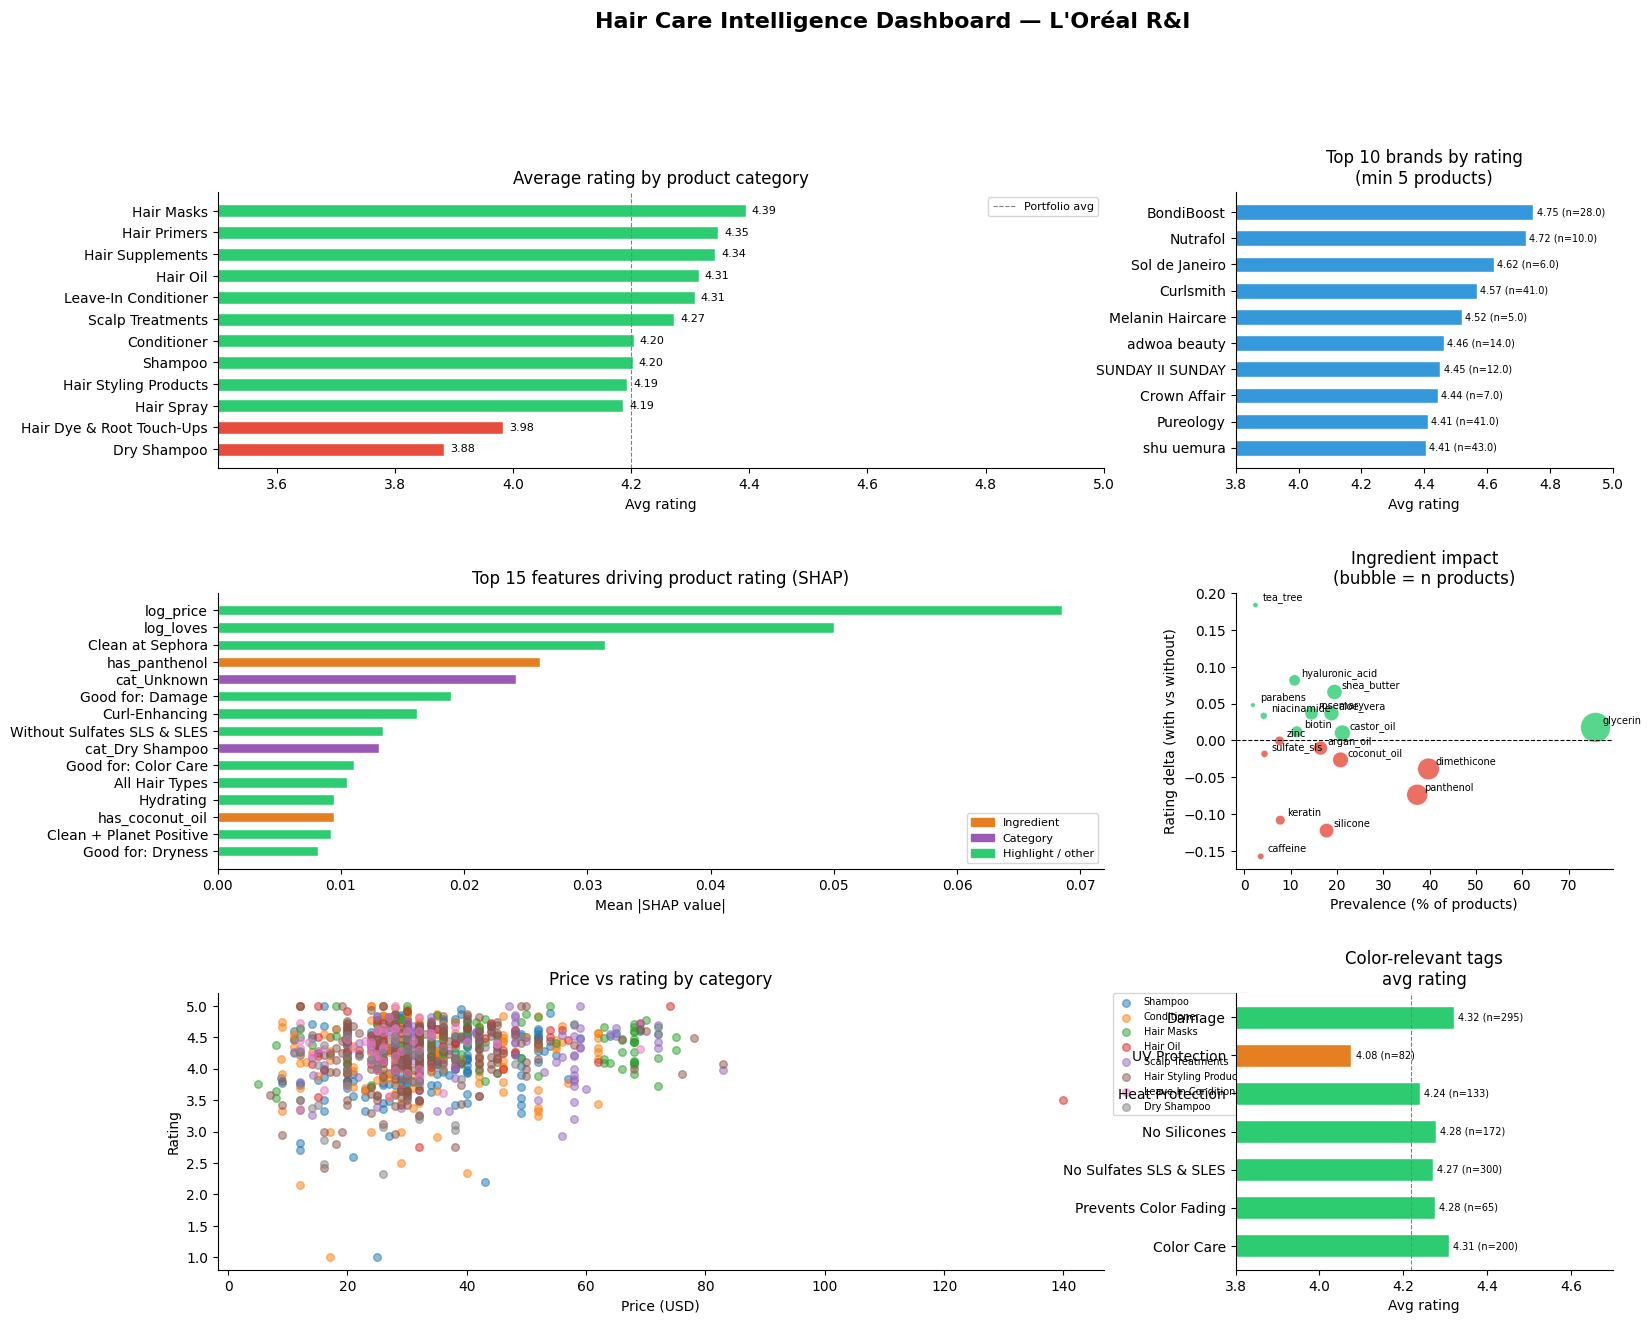

Dashboard saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   12,
    'axes.labelsize':   10,
})

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Hair Care Intelligence Dashboard — L'Oréal R&I",
    fontsize=16, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Avg rating by category (horizontal bar) ──────────────────────
ax1 = fig.add_subplot(gs[0, :2])
cat_rating = hair.groupby('tertiary_category')['rating'].agg(['mean','count'])
cat_rating = cat_rating[cat_rating['count'] >= 5].sort_values('mean')
colors_bar = ['#e74c3c' if r < 4.1 else '#2ecc71' for r in cat_rating['mean']]
bars = ax1.barh(cat_rating.index, cat_rating['mean'],
                color=colors_bar, height=0.6, edgecolor='white')
ax1.axvline(4.2, color='gray', linestyle='--', linewidth=0.8, label='Portfolio avg')
ax1.set_xlabel('Avg rating')
ax1.set_title('Average rating by product category')
ax1.set_xlim(3.5, 5.0)
for bar, val in zip(bars, cat_rating['mean']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)
ax1.legend(fontsize=8)

# ── Plot 2: Top 10 brands by avg rating (min 5 products) ─────────────────
ax2 = fig.add_subplot(gs[0, 2])
brand_stats = hair.groupby('brand_name').agg(
    avg_rating = ('rating', 'mean'),
    n_products = ('rating', 'count'),
    avg_loves  = ('loves_count', 'mean')
).query('n_products >= 5').sort_values('avg_rating', ascending=False).head(10)

ax2.barh(brand_stats.index[::-1], brand_stats['avg_rating'][::-1],
         color='#3498db', height=0.6, edgecolor='white')
ax2.set_xlabel('Avg rating')
ax2.set_title('Top 10 brands by rating\n(min 5 products)')
ax2.set_xlim(3.8, 5.0)
for i, (idx, row) in enumerate(brand_stats[::-1].iterrows()):
    ax2.text(row['avg_rating'] + 0.01, i,
             f"{row['avg_rating']:.2f} (n={row['n_products']})",
             va='center', fontsize=7)

# ── Plot 3: SHAP top 15 feature importance ───────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
top15 = shap_importance.head(15)
colors_shap = ['#e67e22' if 'has_' in f else
               '#9b59b6' if 'cat_' in f else
               '#2ecc71' for f in top15.index]
ax3.barh(top15.index[::-1], top15.values[::-1],
         color=colors_shap[::-1], height=0.6, edgecolor='white')
ax3.set_xlabel('Mean |SHAP value|')
ax3.set_title('Top 15 features driving product rating (SHAP)')

orange = mpatches.Patch(color='#e67e22', label='Ingredient')
purple = mpatches.Patch(color='#9b59b6', label='Category')
green  = mpatches.Patch(color='#2ecc71', label='Highlight / other')
ax3.legend(handles=[orange, purple, green], fontsize=8)

# ── Plot 4: Ingredient prevalence vs rating delta ─────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ing_names, ing_prev, ing_delta, ing_n = [], [], [], []
for col in ingredient_cols:
    name = col.replace('has_', '')
    n    = hair[col].sum()
    if n < 10:
        continue
    prev  = hair[col].mean() * 100
    delta = hair[hair[col]==1]['rating'].mean() - hair[hair[col]==0]['rating'].mean()
    ing_names.append(name)
    ing_prev.append(prev)
    ing_delta.append(delta)
    ing_n.append(n)

scatter_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in ing_delta]
sc = ax4.scatter(ing_prev, ing_delta,
                 s=[n/2 for n in ing_n],
                 c=scatter_colors, alpha=0.8,
                 edgecolors='white', linewidth=0.5)
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, name in enumerate(ing_names):
    ax4.annotate(name, (ing_prev[i], ing_delta[i]),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)
ax4.set_xlabel('Prevalence (% of products)')
ax4.set_ylabel('Rating delta (with vs without)')
ax4.set_title('Ingredient impact\n(bubble = n products)')

# ── Plot 5: Price vs rating by category ──────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
categories_plot = ['Shampoo', 'Conditioner', 'Hair Masks',
                   'Hair Oil', 'Scalp Treatments', 'Hair Styling Products',
                   'Leave-In Conditioner', 'Dry Shampoo']
cat_palette = plt.cm.tab10.colors
for i, cat in enumerate(categories_plot):
    subset = hair[hair['tertiary_category'] == cat]
    if len(subset) < 3:
        continue
    ax5.scatter(subset['price_usd'], subset['rating'],
                alpha=0.5, s=30, color=cat_palette[i], label=cat)
ax5.set_xlabel('Price (USD)')
ax5.set_ylabel('Rating')
ax5.set_title('Price vs rating by category')
ax5.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

# ── Fix Plot 5: move legend outside ──────────────────────────────────────
ax5.legend(fontsize=7, bbox_to_anchor=(1.01, 1),
           loc='upper left', borderaxespad=0)

# ── Fix Plot 6: explicitly clear any inherited artists ───────────────────
ax6.legend_.remove() if ax6.get_legend() else None

# ── Plot 6: Color Care highlight — tag co-occurrence with rating ──────────
ax6 = fig.add_subplot(gs[2, 2])
color_care_tags = [
    'Good for: Color Care', 'Prevents Color Fading',
    'Without Sulfates SLS & SLES', 'Without Silicones',
    'Heat Protection', 'UV Protection', 'Good for: Damage'
]
cc_ratings, cc_labels, cc_ns = [], [], []
for tag in color_care_tags:
    if tag in highlights_df.columns:
        subset = hair[highlights_df[tag] == 1]
        if len(subset) >= 5:
            cc_ratings.append(subset['rating'].mean())
            cc_labels.append(tag.replace('Good for: ', '').replace('Without ', 'No '))
            cc_ns.append(len(subset))

cc_colors = ['#2ecc71' if r >= 4.2 else '#e67e22' for r in cc_ratings]
bars6 = ax6.barh(cc_labels, cc_ratings, color=cc_colors,
                 height=0.6, edgecolor='white')
ax6.axvline(hair['rating'].mean(), color='gray',
            linestyle='--', linewidth=0.8)
ax6.set_xlabel('Avg rating')
ax6.set_title('Color-relevant tags\navg rating')
ax6.set_xlim(3.8, 4.7)
for bar, val, n in zip(bars6, cc_ratings, cc_ns):
    ax6.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f} (n={n})', va='center', fontsize=7)

plt.savefig('haircare_intelligence_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

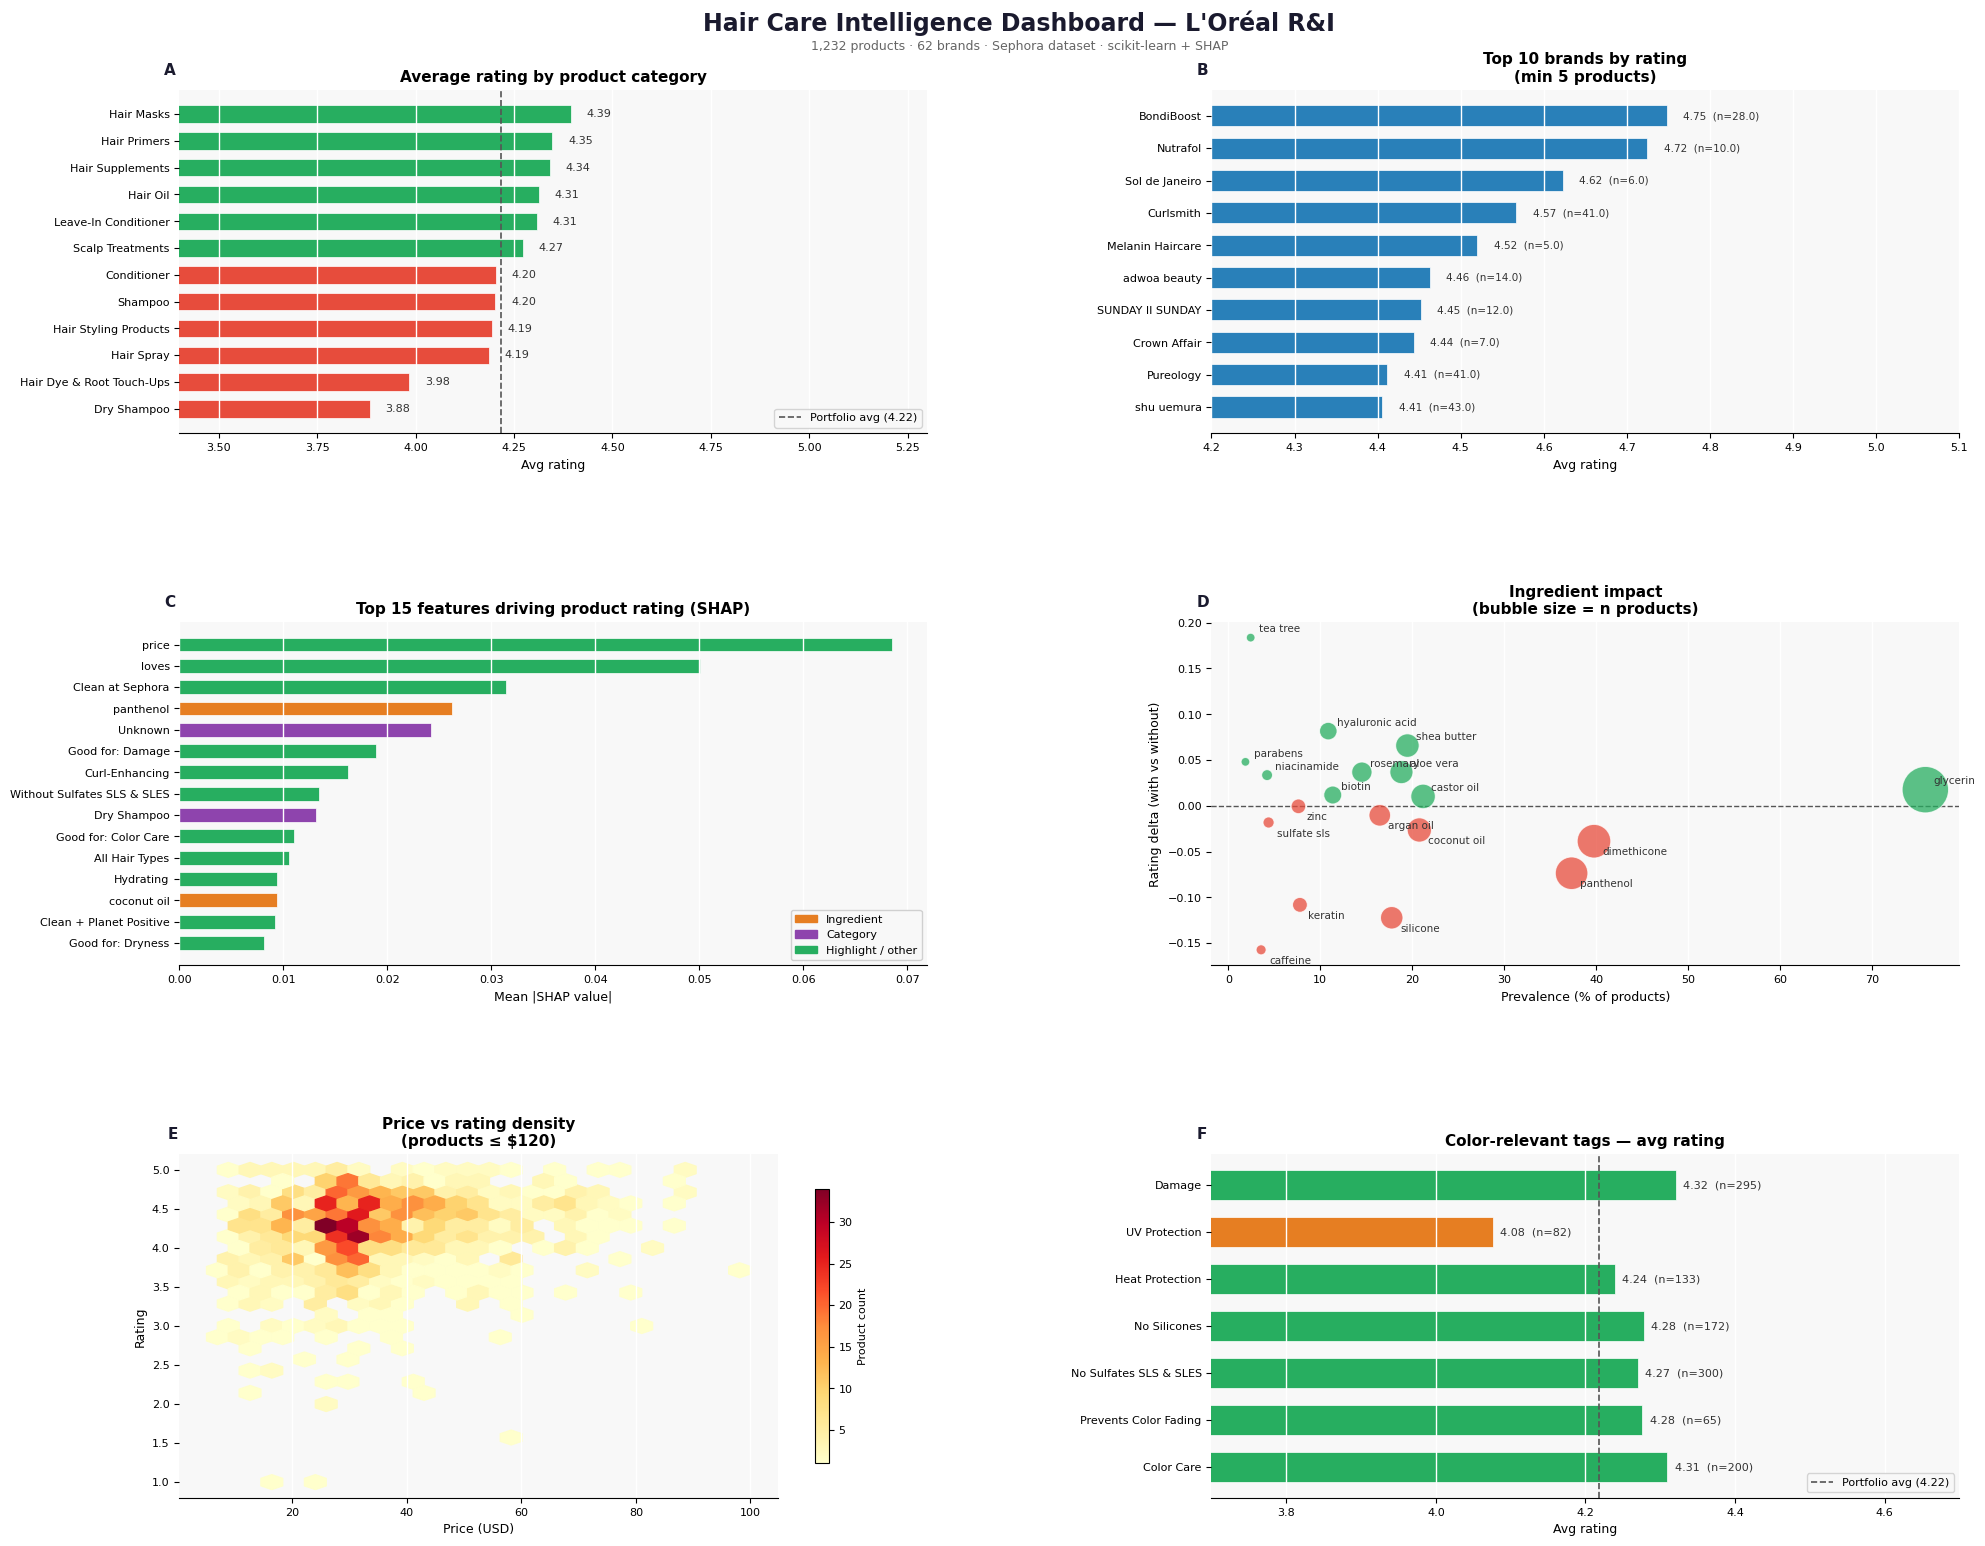

Dashboard v2 saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': True,
    'axes.grid':        True,
    'axes.grid.axis':   'x',
    'grid.color':       'white',
    'grid.linewidth':   1.0,
    'font.family':      'sans-serif',
    'axes.titlesize':   11,
    'axes.titleweight': 'bold',
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
})

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('white')
fig.suptitle(
    "Hair Care Intelligence Dashboard — L'Oréal R&I",
    fontsize=17, fontweight='bold', y=0.98, color='#1a1a2e'
)

gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    hspace=0.55,
    wspace=0.38,
    left=0.08, right=0.97,
    top=0.93, bottom=0.05
)

# ── Plot 1: Avg rating by category ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cat_rating = hair.groupby('tertiary_category')['rating'].agg(['mean','count'])
cat_rating = cat_rating[cat_rating['count'] >= 5].sort_values('mean')
portfolio_avg = hair['rating'].mean()
colors_bar = ['#e74c3c' if r < portfolio_avg else '#27ae60' for r in cat_rating['mean']]
bars = ax1.barh(cat_rating.index, cat_rating['mean'],
                color=colors_bar, height=0.65, edgecolor='white', linewidth=0.5)
ax1.axvline(portfolio_avg, color='#555', linestyle='--',
            linewidth=1.2, label=f'Portfolio avg ({portfolio_avg:.2f})')
ax1.set_xlabel('Avg rating')
ax1.set_title('Average rating by product category')
ax1.set_xlim(3.4, 5.3)   # extend x range to make room for labels
for bar, val in zip(bars, cat_rating['mean']):
    ax1.text(val + 0.04, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8, color='#333')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_facecolor('#f8f8f8')

# ── Plot 2: Top brands by rating ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
brand_stats = hair.groupby('brand_name').agg(
    avg_rating = ('rating', 'mean'),
    n_products = ('rating', 'count'),
).query('n_products >= 5').sort_values('avg_rating', ascending=False).head(10)

y_pos = range(len(brand_stats))
ax2.barh(list(y_pos), brand_stats['avg_rating'].values[::-1],
         color='#2980b9', height=0.65, edgecolor='white', linewidth=0.5)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(brand_stats.index[::-1], fontsize=8)
ax2.set_xlabel('Avg rating')
ax2.set_title('Top 10 brands by rating\n(min 5 products)')
ax2.set_xlim(4.2, 5.1)   # tighter range — all brands are 4.4+
for i, (idx, row) in enumerate(brand_stats[::-1].iterrows()):
    ax2.text(row['avg_rating'] + 0.02, i,
             f"{row['avg_rating']:.2f}  (n={row['n_products']})",
             va='center', fontsize=7.5, color='#333')
ax2.set_facecolor('#f8f8f8')

# ── Plot 3: SHAP top 15 ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
top15 = shap_importance.head(15)
clean_labels = [
    f.replace('has_', '').replace('cat_', '').replace('_', ' ').replace('log ', '')
    for f in top15.index
]
colors_shap = ['#e67e22' if 'has_' in f else
               '#8e44ad' if 'cat_' in f else
               '#27ae60' for f in top15.index]
ax3.barh(clean_labels[::-1], top15.values[::-1],
         color=colors_shap[::-1], height=0.65,
         edgecolor='white', linewidth=0.5)
ax3.set_xlabel('Mean |SHAP value|')
ax3.set_title('Top 15 features driving product rating (SHAP)')
orange = mpatches.Patch(color='#e67e22', label='Ingredient')
purple = mpatches.Patch(color='#8e44ad', label='Category')
green  = mpatches.Patch(color='#27ae60', label='Highlight / other')
ax3.legend(handles=[orange, purple, green], fontsize=8,
           loc='lower right', framealpha=0.9)
ax3.set_facecolor('#f8f8f8')

# ── Plot 4: Ingredient bubble chart ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ing_names, ing_prev, ing_delta, ing_n = [], [], [], []
for col in ingredient_cols:
    name = col.replace('has_', '').replace('_', ' ')
    n    = hair[col].sum()
    if n < 10:
        continue
    prev  = hair[col].mean() * 100
    delta = hair[hair[col]==1]['rating'].mean() - hair[hair[col]==0]['rating'].mean()
    ing_names.append(name)
    ing_prev.append(prev)
    ing_delta.append(delta)
    ing_n.append(n)

scatter_colors = ['#27ae60' if d > 0 else '#e74c3c' for d in ing_delta]
ax4.scatter(ing_prev, ing_delta,
            s=[max(n*1.2, 40) for n in ing_n],
            c=scatter_colors, alpha=0.75,
            edgecolors='white', linewidth=0.8, zorder=3)
ax4.axhline(0, color='#555', linewidth=1.0, linestyle='--', zorder=2)
ax4.set_xlabel('Prevalence (% of products)')
ax4.set_ylabel('Rating delta (with vs without)')
ax4.set_title('Ingredient impact\n(bubble size = n products)')

# Clean non-overlapping labels
for i, name in enumerate(ing_names):
    offset = (6, 4) if ing_delta[i] >= 0 else (6, -10)
    ax4.annotate(name, (ing_prev[i], ing_delta[i]),
                 textcoords='offset points', xytext=offset,
                 fontsize=7.5, color='#333')
ax4.set_facecolor('#f8f8f8')

# ── Plot 5: Price vs rating — use hexbin instead of scatter ──────────────
ax5 = fig.add_subplot(gs[2, 0])
hair_plot = hair[hair['price_usd'] <= 120].copy()
hb = ax5.hexbin(hair_plot['price_usd'], hair_plot['rating'],
                gridsize=25, cmap='YlOrRd', mincnt=1)
cb = fig.colorbar(hb, ax=ax5, shrink=0.8)
cb.set_label('Product count', fontsize=8)
ax5.set_xlabel('Price (USD)')
ax5.set_ylabel('Rating')
ax5.set_title('Price vs rating density\n(products ≤ $120)')
ax5.set_facecolor('#f8f8f8')

# ── Plot 6: Color-relevant tags ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
color_care_tags = [
    'Good for: Color Care',
    'Prevents Color Fading',
    'Without Sulfates SLS & SLES',
    'Without Silicones',
    'Heat Protection',
    'UV Protection',
    'Good for: Damage',
]
cc_ratings, cc_labels, cc_ns = [], [], []
for tag in color_care_tags:
    if tag in highlights_df.columns:
        subset = hair[highlights_df[tag] == 1]
        if len(subset) >= 5:
            cc_ratings.append(subset['rating'].mean())
            cc_labels.append(
                tag.replace('Good for: ', '')
                   .replace('Without ', 'No ')
            )
            cc_ns.append(len(subset))

cc_colors = ['#27ae60' if r >= portfolio_avg else '#e67e22' for r in cc_ratings]
bars6 = ax6.barh(cc_labels, cc_ratings, color=cc_colors,
                 height=0.65, edgecolor='white', linewidth=0.5)
ax6.axvline(portfolio_avg, color='#555', linestyle='--',
            linewidth=1.2, label=f'Portfolio avg ({portfolio_avg:.2f})')
ax6.set_xlabel('Avg rating')
ax6.set_title('Color-relevant tags — avg rating')
ax6.set_xlim(3.7, 4.7)
ax6.legend(fontsize=8, loc='lower right')
for bar, val, n in zip(bars6, cc_ratings, cc_ns):
    ax6.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}  (n={n})', va='center', fontsize=8, color='#333')
ax6.set_facecolor('#f8f8f8')

# ── Add a thin subtitle under the main title ─────────────────────────────
fig.text(0.5, 0.955,
         '1,232 products · 62 brands · Sephora dataset · scikit-learn + SHAP',
         ha='center', fontsize=9, color='#666')

# ── Add panel letters for easy reference in write-up ─────────────────────
for ax, letter in zip(
    [ax1, ax2, ax3, ax4, ax5, ax6],
    ['A', 'B', 'C', 'D', 'E', 'F']
):
    ax.text(-0.02, 1.08, letter, transform=ax.transAxes,
            fontsize=11, fontweight='bold', color='#1a1a2e', va='top')

plt.savefig('haircare_intelligence_dashboard_v2.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard v2 saved.")